# Машинное обучение, ФКН ВШЭ

# Практическое задание 10. Обучение без учителя.

## Общая информация
Дата выдачи: 26.03.2025

Мягкий дедлайн: 13.04.2025 23:59 MSK

Жёсткий дедлайн: 17.04.2025 23:59 MSK

## Оценивание и штрафы

Каждая из задач имеет определенную «стоимость» (указана в скобках около задачи).

Сдавать задание после указанного срока сдачи нельзя.

Задание выполняется самостоятельно. «Похожие» решения считаются плагиатом и все задействованные студенты (в том числе те, у кого списали) не могут получить за него больше 0 баллов (подробнее о плагиате см. на странице курса). Если вы нашли решение какого-то из заданий (или его часть) в открытом источнике, необходимо указать ссылку на этот источник в отдельном блоке в конце вашей работы (скорее всего вы будете не единственным, кто это нашел, поэтому чтобы исключить подозрение в плагиате, необходима ссылка на источник).

Неэффективная реализация кода может негативно отразиться на оценке.

## Формат сдачи
Задания сдаются через систему anytask. Посылка должна содержать:
* Ноутбук homework-practice-10-Username.ipynb

Username — ваша фамилия на латинице

## О задании

В этом задании мы посмотрим на несколько алгоритмов кластеризации и применим их к географическим и текстовым данным. Также мы подробно остановимся на тематическом моделировании текстов, задаче обучения представлений и в каком-то смысле поработаем с semi-supervised learning.



In [1]:
import pandas as pd
import numpy as np

np.random.seed(0xFFFFFFF)

**Задание 0 (1e-100 балла)**. Опишите свои ощущения от домашки по ЕМ-алгоритму (можно картинкой или мемом).

In [2]:
# YOUR CODE HERE (ノಠ益ಠ)ノ彡┻━┻
# это был мрак

## Часть 1. Кластеризация автобусных остановок

В этом задании мы сравним разные алгоритмы кластеризации для данных об автобусных остановках Москвы.

**Задание 1.1 (1 балл).** Реализуйте алгоритм спектральной кластеризации, который упоминался на лекции. Для этого разберитесь с кодом шаблона, данного ниже, и допишите недостающую функцию. Напомним, что для графа с матрицей смежности $W = \{w_{ij}\}_{i, j = 1 \dots \ell}$ лапласиан определяется как:

$$
L = D - W,
$$

где $D = \text{diag}(d_1, ..., d_{\ell}), d_i = \sum_{j=1}^{\ell} w_{ij}$.

In [3]:
from sklearn.base import ClusterMixin
from sklearn.cluster import KMeans
import numpy as np
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import eigsh

class GraphClustering(ClusterMixin):
    def __init__(self, n_clusters=8, n_components=None, **kwargs):
        '''
        Spectral clustering algorithm
        param n_clusters: number of clusters to form
        param n_components: number of eigenvectors to use
        '''

        if n_components is None:
            n_components = n_clusters

        self.n_components = n_components
        self.kmeans = KMeans(n_clusters=n_clusters, **kwargs)

    def fit_predict(self, X, y=None):
        '''
        Perform spectral clustering from graph adjacency matrix
        and return vertex labels.
        param X: (n_samples, n_samples) - graph adjacency matrix
        return: (n_samples, ) - vertex labels
        '''

        eigenvectors = self._generate_eigenvectors(X)
        labels = self.kmeans.fit_predict(eigenvectors[:, 1:])
        return labels
    def _generate_eigenvectors(self, X):
        '''
        Compute eigenvectors for spectral clustering
        param X: (n_samples, n_samples) - graph adjacency matrix
        return: (n_samples, n_components) - eigenvectors
        '''
        n = X.shape[0]
        degrees = np.zeros(n)
        for i in range(n):
            degrees[i] = X[i].sum() 
    
        D = diags(degrees, format='csr')
        L = D - X
    
        eigenvalues, eigenvectors = eigsh(L, k=self.n_components, which='SM')
        return eigenvectors

Перед тем, как переходить к следующему заданию, протестируйте свое решение.

In [4]:
n_blocks, n_vertices = 10, 1000
block_vertices = n_vertices // n_blocks

X = np.zeros((n_vertices, n_vertices))
for i in range(0, n_vertices, block_vertices):
    X[i:i + block_vertices, i:i + block_vertices] = np.sqrt(i + 1)

graph_clustering = GraphClustering(n_clusters=n_blocks)
labels = graph_clustering.fit_predict(X)

true_labels = np.zeros(n_vertices, dtype=np.int32)
for i in range(0, n_vertices, block_vertices):
    true_labels[i:i + block_vertices] = labels[i]

assert labels.shape == (n_vertices, )
assert np.all(np.bincount(labels) == np.full(n_blocks, block_vertices))
assert np.all(labels == true_labels)

Теперь можем приступить к работе с реальными данными. Скачайте файл с данными об остановках общественного транспорта **в формате .xlsx** по [ссылке](https://data.mos.ru/opendata/download/60464/1/201) (так гарантированно не возникнет проблем с парсингом файла) и загрузите таблицу в ноутбук. Альтернативная ссылка: [отсюда](https://disk.yandex.ru/i/J0HlcDXd_KyIeg). Для удобства визуализации мы будем работать только с остановками в ЦАО.

In [5]:
data = pd.read_excel('transport.xlsx')
data = data[data.AdmArea_en == "Czentral`ny'j administrativny'j okrug"]
data = data.reset_index()
data.head()

,index,ID_en,Name_en,Longitude_WGS84_en,Latitude_WGS84_en,Street_en,AdmArea_en,District_en,RouteNumbers_en,StationName_en,Direction_en,Pavilion_en,OperatingOrgName_en,EntryState_en,global_id,geoData
0,278,347,"«2-й Лесной пер.», улица Бутырский Вал (347)",37.586584,55.782106,улица Бутырский Вал,Czentral`ny'j administrativny'j okrug,Tverskoj rajon,АТ18; А12; АТ56; АТ78,2-й Лесной пер.,NaN,да,ГУП «Мосгортранс»,active,889085436,NaN
1,279,349,"«Ул. Сущевский Вал», Новослободская улица (349)",37.590714,55.790630,Новослободская улица,Czentral`ny'j administrativny'j okrug,Tverskoj rajon,АТ47; АМ10; АТ3; АТ56; АТ78,Ул. Сущевский Вал,NaN,да,ГУП «Мосгортранс»,active,889085437,NaN
2,355,479,"«Стадион Лужники (южн.) (пос.)», улица Лужники...",37.565972,55.714265,улица Лужники,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Стадион Лужники (южн.) (пос.),NaN,да,ГУП «Мосгортранс»,active,889085549,NaN
3,356,480,"«Спортзал Дружба», Лужнецкая набережная (480)",37.570191,55.712504,Лужнецкая набережная,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Спортзал Дружба,NaN,да,ГУП «Мосгортранс»,active,889085550,NaN
4,357,481,"«Лужнецкая наб.», Лужнецкая набережная (481)",37.574559,55.713770,Лужнецкая набережная,Czentral`ny'j administrativny'j okrug,rajon Xamovniki,А64; А216; А809; АС12; А255; АБК; АТ79,Лужнецкая наб.,NaN,да,ГУП «Мосгортранс»,active,889085551,NaN


Воспользуемся библиотекой `folium` для визуализации данных.

In [6]:
import folium

map = folium.Map([55.75215, 37.61819], zoom_start=12)
for id, row in data.iterrows():
    folium.Circle([row.Latitude_WGS84_en, row.Longitude_WGS84_en],
                  radius=10).add_to(map)
map

**Задание 1.2 (1 балл).** Попробуем построить граф, в котором вершинами будут остановки. Как вы уже могли заметить, для каждой остановки указаны номера маршрутов, проходящих через неё. Логично соединить ребрами соседние остановки каждого маршрута. Однако мы не знаем, в каком порядке автобусы объезжают остановки. Но мы можем применить эвристический алгоритм, который восстановит нам порядок маршрутов:

* Для каждого маршрута выделим список всех остановок, через которые он проходит.
* Выберем начальную остановку маршрута как точку, наиболее удаленную от всех остальных остановок этого маршрута.
* Каждую следующую точку маршрута будем выбирать как самую близкую из оставшихся точек (не включенных в маршрут ранее).

Фактически, у нас получается жадное решение задачи коммивояжера. Когда мы отсортировали маршруты, можем построить по ним граф. Будем строить его по таким правилам:

* Между двумя остановками будет ребро, если они являются соседними хотя бы на одном маршруте. Вес ребра равен числу маршрутов, на которых остановки являются соседними.
* В графе не будет петель (то есть у матрицы смежности будет нулевая диагональ).

Реализуйте предложенный способ построения графа. Для этого рекомендуется воспользоваться шаблонами, приведенными ниже.

In [7]:
import numpy as np
import pandas as pd
from typing import Dict, List, Set, Tuple

def extract_routes(data: pd.DataFrame) -> Dict[str, List[str]]:
    routes: Dict[str, Set[str]] = {}
    for _, row in data.iterrows():
        stop_id = row['ID_en']
        route_str = row['RouteNumbers_en']
        if pd.isna(route_str):
            continue
        route_list = [r.strip() for r in str(route_str).split(';') if r.strip()]
        for route in route_list:
            routes.setdefault(route, set()).add(stop_id)
    return {route: list(stops) for route, stops in routes.items()}


def _squared_distance(coord1: Tuple[float, float], coord2: Tuple[float, float]) -> float:
    lat1, lon1 = coord1
    lat2, lon2 = coord2
    return (lat1 - lat2) ** 2 + (lon1 - lon2) ** 2


def _choose_starting_stop(stops: List[str], coords: Dict[str, Tuple[float, float]]) -> str:
    if len(stops) <= 1:
        return stops[0]

    best_stop = None
    best_min_dist = -1.0

    for i, stop_i in enumerate(stops):
        min_dist = float('inf')
        for j, stop_j in enumerate(stops):
            if i == j:
                continue
            d = _squared_distance(coords[stop_i], coords[stop_j])
            if d < min_dist:
                min_dist = d
        if min_dist > best_min_dist:
            best_min_dist = min_dist
            best_stop = stop_i
    return best_stop


def _order_stops_greedy(stops: List[str], coords: Dict[str, Tuple[float, float]]) -> List[str]:
    if len(stops) <= 1:
        return stops[:]

    start = _choose_starting_stop(stops, coords)
    ordered = [start]
    remaining = set(stops) - {start}

    while remaining:
        current = ordered[-1]
        best = min(remaining, key=lambda s: _squared_distance(coords[current], coords[s]))
        ordered.append(best)
        remaining.remove(best)

    return ordered


def sort_routes(data: pd.DataFrame, routes: Dict[str, List[str]]) -> Dict[str, List[str]]:
    coords: Dict[str, Tuple[float, float]] = {}
    for _, row in data.iterrows():
        stop_id = row['ID_en']
        lat = row['Latitude_WGS84_en']
        lon = row['Longitude_WGS84_en']
        if pd.notna(lat) and pd.notna(lon):
            coords[stop_id] = (lat, lon)

    sorted_routes: Dict[str, List[str]] = {}
    for route, stops in routes.items():
        valid_stops = [s for s in stops if s in coords]
        if not valid_stops:
            sorted_routes[route] = []
            continue
        sorted_routes[route] = _order_stops_greedy(valid_stops, coords)

    return sorted_routes


def build_adjacency_matrix(sorted_routes: Dict[str, List[str]]) -> np.ndarray:
    all_stops = set()
    for stops in sorted_routes.values():
        all_stops.update(stops)

    stop_ids = list(all_stops)
    n = len(stop_ids)
    id_to_idx = {sid: i for i, sid in enumerate(stop_ids)}

    adj = np.zeros((n, n), dtype=int)

    for stops in sorted_routes.values():
        if len(stops) < 2:
            continue
        for i in range(len(stops) - 1):
            a = stops[i]
            b = stops[i + 1]
            idx_a = id_to_idx[a]
            idx_b = id_to_idx[b]
            adj[idx_a, idx_b] += 1
            adj[idx_b, idx_a] += 1

    return adj

Проверим, что маршруты получились адекватными. Для этого нарисуем их на карте.

In [8]:
routes = extract_routes(data) 
sorted_routes = sort_routes(data, routes)
adjacency_matrix = build_adjacency_matrix(sorted_routes)

m = folium.Map([55.75215, 37.61819], zoom_start=12)

for route_id, stops in sorted_routes.items():
    route_coords = []
    for stop in stops:
        row = data[data['ID_en'] == stop]
        if not row.empty:
            lat = row.iloc[0]['Latitude_WGS84_en']
            lon = row.iloc[0]['Longitude_WGS84_en']
            route_coords.append([lat, lon])
    if len(route_coords) >= 2:
        folium.PolyLine(route_coords).add_to(m)
m

**Задание 1.3 (0 баллов)**. Реализуйте функцию `draw_clustered_map`, которая рисует карту центра Москвы с кластерами остановок, раскрашенными в разные цвета.

In [29]:
import matplotlib.cm as cm
from matplotlib.colors import to_hex

def draw_clustered_map(data: pd.DataFrame, labels_series: pd.Series, adj_matrix: np.ndarray = None):

    m = folium.Map(location=[55.751244, 37.618423], zoom_start=12)

    has_coords = data[['Latitude_WGS84_en', 'Longitude_WGS84_en']].notna().all(axis=1)
    valid_indices = (data.index.isin(labels_series.index) & 
                     has_coords & 
                     (labels_series != -1))
    
    if not valid_indices.any():
        print("Нет валидных точек для отображения")
        return m

    filtered = data[valid_indices].copy()
    filtered['cluster'] = labels_series.loc[filtered.index]

    unique_clusters = filtered['cluster'].unique()
    n_clusters = len(unique_clusters)
    
    if n_clusters == 0:
        return m
    
    if n_clusters <= 10:
        cmap = cm.get_cmap('tab10')
    elif n_clusters <= 20:
        cmap = cm.get_cmap('tab20')
    else:
        cmap = cm.get_cmap('viridis')

    labels_norm = (filtered['cluster'] - filtered['cluster'].min()) / (filtered['cluster'].max() - filtered['cluster'].min() + 1e-8)

    for idx, row in filtered.iterrows():
        cluster_id = row['cluster']
        color = to_hex(cmap(labels_norm.loc[idx]))
        
        popup_text = f"Остановка: {row['ID_en']}<br>Кластер: {cluster_id}"
        
        if adj_matrix is not None:
            stop_idx = list(labels_series.index).index(idx)
            degree = np.sum(adj_matrix[stop_idx]) if stop_idx < adj_matrix.shape[0] else 0
            popup_text += f"<br>Маршрутов: {degree}"

        folium.CircleMarker(
            location=[row['Latitude_WGS84_en'], row['Longitude_WGS84_en']],
            radius=4,
            color=color,
            weight=1,
            fill=True,
            fillColor=color,
            fillOpacity=0.8,
            popup=popup_text
        ).add_to(m)

    return m

**Задание 1.4 (1.5 балла)**. Примените алгоритмы кластеризации и подберите гиперпараметры так, чтобы кластеры получились осмысленными (нет такого, что все принадлежит одному кластеру или большая часть точек это шум):
- `sklearn.clustering.KMeans` - `n_clusters`
- `sklearn.clustering.DBSCAN` - `eps`
- ваш `SpectralClustering` - `n_clusters` и `n_components`

Для ряда алгоритмов, в частности DBSCAN, подобрать оптимальные параметры может быть ой, как непросто. Чтобы помочь сохранить нервные клетки рекомендуется пользоваться метриками Intrinsic Evaluation для кластеризации. Для каждого алгоритма скорее всего придется брать разные метрики, а может быть оптимизировать сразу несколько.

Ваша задача - выбрать подходящую метрику, можно взять что-то из списка ниже, можно спросить у гугла. Применить GridSearch, `optuna` или `hyperopt` и желательно завернуть отбор параметров в функцию, пригодится далее

1. $
   \text{Calinski-Harabasz Index} \in [0, \inf] = \frac{\sum_{i=1}^k BCSS_i/(k-1)}{\sum_{i=1}^k WCSS_i/(n-k)} = \frac{\sum_{i=1}^k n_i \| \mathbf{c}_i - \mathbf{c} \|^2/(k-1)}{\sum_{i=1}^k \sum_{\mathbf{x} \in C_i} \|\mathbf{x} - \mathbf{c}_i\|^2/(n-k)} \rightarrow max
   $
   - Отношение 1) расстояния от центра кластера до центра всех данных к 2) расстоянию от центра кластера до точки
   - Чем однороднее и дальше друг от друга кластеры, тем лучше
2. $
   \text{Silhouette Score} \in [0, 1] = \sum_i \frac{b_i - a_i}{\max(a_i, b_i)} \rightarrow max
   $
   - $a_i$ - среднее расстояние до точек внутри своего кластера
   - $b_i$ - среднее расстояние до точек из ближайшего кластера
   - Если в своем кластере точки близко - кластер плотный, идеальный вариант, скор равен 1, если свой кластер совпадает с соседним - кластеры неразделимы, скор равен нулю
   - Чем однороднее и разделимее кластеры, тем лучше
3. $\text{Davies-Bouldin Index} \in [0, inf] = \frac{1}{k} \sum_{i=1}^{k} \max_{j \neq i} \left( \frac{WCSS_i + WCSS_j}{d(c_i, c_j)} \right) \rightarrow min $
   - Отношение внутрикластерных расстояний к межкластерному расстоянию между двумя центрами
   - Если кластеры далеко друг от друга, но при этом однородные, скор наименьший
3. $\text{Elbow Method}$ - последовательное сравнение $WCSS$ из пункта 1 для разного числа параметров. Если уменьшение меньше определенного порога - останавливаемся, считаем это значение оптимальным

In [45]:
import optuna
import numpy as np
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score

def objective(trial, X, algorithm, random_state=42):
    if algorithm == 'kmeans':
        n_clusters = trial.suggest_int('n_clusters', 2, min(20, len(np.unique(X, 0))))
        model = KMeans(n_clusters=n_clusters, random_state=random_state, n_init='auto')
        labels = model.fit_predict(X)
        return calinski_harabasz_score(X, labels) if len(np.unique(labels)) >= 2 else -1
    
    elif algorithm == 'dbscan':
        X_unique = np.unique(X, axis=0)
        if len(X_unique) < 20: return -1
        eps = trial.suggest_float('eps', 0.0005, 0.05, log=True)
        min_samples = trial.suggest_int('min_samples', 3, min(20, len(X_unique)//5))
        model = DBSCAN(eps=eps, min_samples=min_samples)
        labels = model.fit_predict(X_unique)
        n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
        if n_clusters < 2 or np.mean(labels == -1) > 0.5: return -1
        return silhouette_score(X_unique[labels != -1], labels[labels != -1])
    
    elif algorithm == 'spectral':
        n_clusters = trial.suggest_int('n_clusters', 2, min(20, len(np.unique(X, 0))))
        n_components = trial.suggest_int('n_components', n_clusters, min(X.shape[0]-1, n_clusters*2))
        model = SpectralClustering(n_clusters=n_clusters, n_components=n_components, 
                                 random_state=random_state, affinity='rbf')
        labels = model.fit_predict(X)
        return calinski_harabasz_score(X, labels) if len(np.unique(labels)) >= 2 else -1

def tune_clustering(X, algorithm, n_trials=150):
    study = optuna.create_study(direction='maximize')
    study.optimize(lambda trial: objective(trial, X, algorithm), n_trials=n_trials, show_progress_bar=True)
    return study.best_params, study.best_value

In [46]:
params_kmeans, _ = tune_clustering(X, 'kmeans')
params_dbscan, _ = tune_clustering(X, 'dbscan')
params_spec, _ = tune_clustering(X, 'spectral')

[I 2026-03-30 19:31:11,299] A new study created in memory with name: no-name-08ddd856-564c-40b6-af52-12c03cf9c8f7


  0%|          | 0/150 [00:00<?, ?it/s]

/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (10) found smaller than n_clusters (11). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


[I 2026-03-30 19:31:11,358] Trial 0 finished with value: 422.1312292358802 and parameters: {'n_clusters': 5}. Best is trial 0 with value: 422.1312292358802.
[I 2026-03-30 19:31:11,398] Trial 1 finished with value: 519.1085409252665 and parameters: {'n_clusters': 6}. Best is trial 1 with value: 519.1085409252665.
[I 2026-03-30 19:31:11,428] Trial 2 finished with value: 295.11846828879146 and parameters: {'n_clusters': 4}. Best is trial 1 with value: 519.1085409252665.
[I 2026-03-30 19:31:11,457] Trial 3 finished with value: 295.11846828879146 and parameters: {'n_clusters': 4}. Best is trial 1 with value: 519.1085409252665.
[I 2026-03-30 19:31:11,500] Trial 4 finished with value: 4.558580190849724e+31 and parameters: {'n_clusters': 11}. Best is trial 4 with value: 4.558580190849724e+31.
[I 2026-03-30 19:31:11,551] Trial 5 finished with value: 295.11846828879146 and parameters: {'n_clusters': 4}. Best is trial 4 with value: 4.558580190849724e+31.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/base.py:1365: ConvergenceWarning: Number of distinct clusters (10) found smaller than n_clusters (11). Possibly due to duplicate points in X.
  return fit_method(estimator, *args, **kwargs)


...

[I 2026-03-30 19:31:43,521] Trial 144 finished with value: 1308.628205128204 and parameters: {'n_clusters': 9, 'n_components': 12}. Best is trial 0 with value: 4.558580190849724e+31.
[I 2026-03-30 19:31:43,640] Trial 145 finished with value: 49884.999999999935 and parameters: {'n_clusters': 10, 'n_components': 18}. Best is trial 0 with value: 4.558580190849724e+31.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_spectral.py:706: UserWa

[I 2026-03-30 19:31:43,741] Trial 146 finished with value: 4.558580190849724e+31 and parameters: {'n_clusters': 10, 'n_components': 19}. Best is trial 0 with value: 4.558580190849724e+31.
[I 2026-03-30 19:31:43,832] Trial 147 finished with value: 16011.899793601639 and parameters: {'n_clusters': 11, 'n_components': 20}. Best is trial 0 with value: 4.558580190849724e+31.


/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/cluster/_spectral.py:706: UserWarning: The spectral clustering API has changed. ``fit``now constructs an affinity matrix from data. To use a custom affinity matrix, set ``affinity=precomputed``.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:328: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


[I 2026-03-30 19:31:43,988] Trial 148 finished with value: 4.558580190849724e+31 and parameters: {'n_clusters': 10, 'n_components': 19}. Best is trial 0 with value: 4.558580190849724e+31.
[I 2026-03-30 19:31:44,079] Trial 149 finished with value: 4.558580190849724e+31 and parameters: {'n_clusters': 10, 'n_components': 19}. Best is trial 0 with value: 4.558580190849724e+31.


Визуализируйте результат кластеризации с помощью функции `draw_clustered_map`.

In [47]:
coords = data[['Latitude_WGS84_en', 'Longitude_WGS84_en']].dropna()
coords_index = coords.index

scaler = StandardScaler()
X_scaled = scaler.fit_transform(coords[['Latitude_WGS84_en', 'Longitude_WGS84_en']])

kmeans_model = KMeans(**params_kmeans, random_state=42, n_init='auto')
kmeans_labels = kmeans_model.fit_predict(X_scaled)
kmeans_labels_series = pd.Series(kmeans_labels, index=coords_index)

dbscan_model = DBSCAN(**params_dbscan)
dbscan_labels = dbscan_model.fit_predict(X_scaled)
dbscan_labels_series = pd.Series(dbscan_labels, index=coords_index)

spectral_model = SpectralClustering(**params_spec, random_state=42, affinity='rbf', eigen_solver='arpack')
spectral_labels = spectral_model.fit_predict(X_scaled)
spectral_labels_series = pd.Series(spectral_labels, index=coords_index)

map_kmeans = draw_clustered_map(data, kmeans_labels_series)
map_dbscan = draw_clustered_map(data, dbscan_labels_series)
map_spectral = draw_clustered_map(data, spectral_labels_series)

/var/folders/z5/3lbr_mgd2vs1f1qrg87y967h0000gn/T/ipykernel_11973/3860739864.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20')
/var/folders/z5/3lbr_mgd2vs1f1qrg87y967h0000gn/T/ipykernel_11973/3860739864.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')
/var/folders/z5/3lbr_mgd2vs1f1qrg87y967h0000gn/T/ipykernel_11973/3860739864.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab

In [48]:
map_kmeans

In [49]:
map_dbscan

In [50]:
map_spectral

**Вопрос:** Чем отличаются разбиения на кластеры, получаемые разными алгоритмами? Какие плюсы и минусы есть у каждого алгоритма? Какой алгоритм кажется вам наиболее подходящим для кластеризации остановок?

**Ответ:** Лучшим вариантом оказалась спектральная кластеризация. Почему? 

Мы видим хорошее разбиение на районы, за исключением большого кластера в самом центре, оранжевый кластер слишком зашел к басманному району, а в остальном все отлично, есть несколько выбросов, но в целом хорошо реагирует алгоритм. Можно еще заметить, что ближе к ттк алгоритм начинает сомневаться и путать кластеры - это видно на красных точках на фрунзенской и красной пресне. 

Kmeans отработал неплохо, очень остро разбил на кластеры, но мне кажется это хуже, так как сложнее такое интерпретировать в проде. Если уменьшить принудительно число кластеров, получится лучше.

DBSCAN не смог у меня отработать на датасете

## Часть 2. Тематическое моделирование текстов

В этой части мы познакомимся с одной из самых популярных задач обучения без учителя &mdash; с задачей тематического моделирования текстов. Допустим, нам доступна некоторая коллекция документов без разметки, и мы хотим автоматически выделить несколько тем, которые встречаются в документах, а также присвоить каждому документу одну (или несколько) тем. Фактически, мы будем решать задачу, похожую на кластеризацию текстов: отличие в том, что нас будет интересовать не только разбиение текстов на группы, но и выделение ключевых слов, определяющих каждую тему.

Мы будем работать с новостными статьями BBC за 2004-2005 годы. Скачайте данные по [ссылке](https://www.kaggle.com/hgultekin/bbcnewsarchive).

In [52]:
data = pd.read_csv('bbc-news-data.csv', sep='\t')
data.sample(5)

,category,filename,title,content
1120,politics,225.txt,Blair to face MPs amid feud talk,Tony Blair faces his first prime minister's q...
1659,sport,347.txt,Moore questions captaincy,Brian Moore believes the England captain shou...
950,politics,055.txt,Kelly trails new discipline power,Teachers could get more powers to remove unru...
18,business,019.txt,India widens access to telecoms,India has raised the limit for foreign direct...
214,business,215.txt,SEC to rethink post-Enron rules,The US stock market watchdog's chairman has s...


Как вы могли заметить, данные уже содержат разметку по тематике (колонка category). В этой части мы забудем, что она есть, и будем работать только с текстовыми данными. Проведем предобработку текста, состоящую из следующих пунктов:

* Объединим заголовок и содержание статьи в одно поле.
* Приведем текст к нижнему регистру, разобьем его на токены.
* Оставим только буквенные слова (удалив, таким образом, пунктуацию и числа).
* Применим лемматизацию.
* Удалим стоп-слова.


In [53]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

In [57]:
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

stop_words = set(stopwords.words('english') + ['ha', 'wa', 'say', 'said'])
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/nikitasorokin/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/nikitasorokin/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/nikitasorokin/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [58]:
def preprocess(text):
    text = list(filter(str.isalpha, word_tokenize(text.lower())))
    text = list(lemmatizer.lemmatize(word) for word in text)
    text = list(word for word in text if word not in stop_words)
    return ' '.join(text)

In [59]:
data['raw_text'] = data.apply(lambda row: row.title + row.content, axis=1)
data['text'] = data.apply(lambda row: preprocess(row.raw_text), axis=1)

Для визуализации частот слов в текстах мы будем использовать [облака тегов](https://en.wikipedia.org/wiki/Tag_cloud).

In [62]:
!pip install wordcloud

In [63]:
from wordcloud import WordCloud

def draw_wordcloud(texts, max_words=1000, width=1000, height=500):
    wordcloud = WordCloud(background_color='white', max_words=max_words,
                          width=width, height=height)

    joint_texts = ' '.join(list(texts))
    wordcloud.generate(joint_texts)
    return wordcloud.to_image()

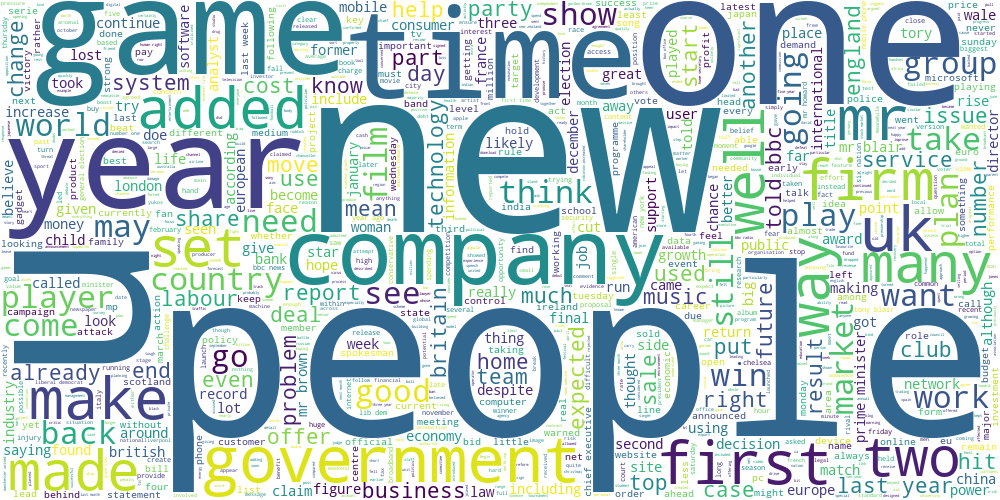

In [64]:
draw_wordcloud(data.text)

**Задание 2.1 (1 балл).** Обучите алгоритм K-Means на tf-idf представлениях текстов. При обучении tf-idf векторайзера рекомендуется отбрасывать редко встречающиеся слова, а также воздержитесь от использования N-грамм. Возьмите не очень большое число кластеров, чтобы было удобно интерпретировать получившиеся темы (например, `n_clusters` = 8). Постройте облака тегов для текстов из разных кластеров.

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_df = 0.5,
    min_df = 5
)

X_tfidf = vectorizer.fit_transform(data['text'])

In [96]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=8,
    max_iter=300,
    n_init=10,
    random_state = 42
)

cluster_labels_kmeans = kmeans.fit_predict(X_tfidf)

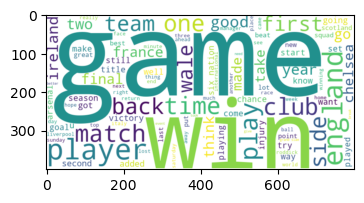

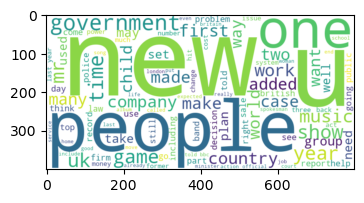

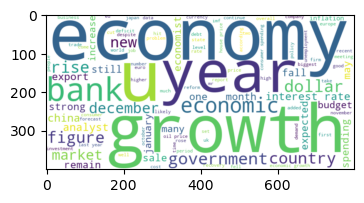

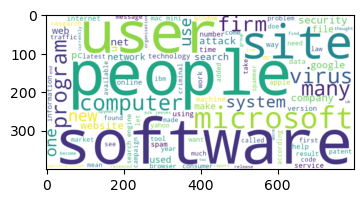

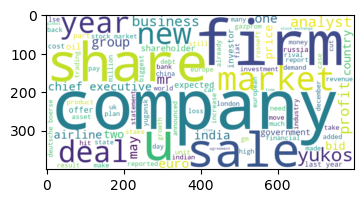

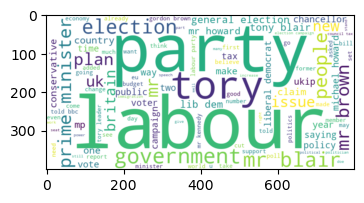

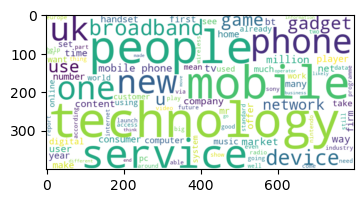

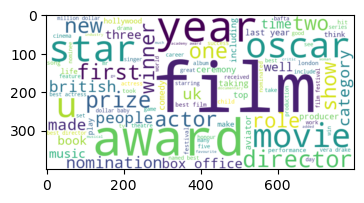

In [97]:
import matplotlib.pyplot as plt
data['cluster_kmeans'] = cluster_labels_kmeans

def plot_wordcloud_for_cluster(cluster_id, texts):
    text = " ".join(texts)
    wordcloud = WordCloud(width=800, height=400, max_words=100, background_color="white").generate(text)
    plt.figure(figsize=(4, 2))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.show()

for cl in range(8):
    texts_in_cluster = data[data["cluster_kmeans"] == cl]["text"]
    plot_wordcloud_for_cluster(cl, texts_in_cluster)

Получились ли темы интерпретируемыми? Попробуйте озаглавить каждую тему.

**Ответ:** да, вполне интерпретируемые темы:

0. Футбоольчик тема
1. Тут тяжело, наверное политическая
2. Экономическая очев
3. Тема для разработчиков
4. Бытовая тема
5. хз
6. Про технологии
7. Киношная тема

**Задание 2.2 (0.5 балла).** Попробуем другой способ выделить ключевые слова для каждой темы. Помимо непосредственного разбиения объектов алгоритм K-Means получает центр каждого кластера. Попробуйте взять центры кластеров и посмотреть на слова, для которых значения соответствующих им признаков максимальны.

In [84]:
centers = kmeans.cluster_centers_
order_centroids = centers.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(8):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()

Cluster 0: game england player win match cup club team champion injury 
Cluster 1: mr new music show government people game one band uk 
Cluster 2: economy growth rate bank economic dollar figure price rise deficit 
Cluster 3: software site user program microsoft virus search computer security system 
Cluster 4: company firm share profit sale oil market yukos price airline 
Cluster 5: mr labour election party blair tory brown tax howard minister 
Cluster 6: mobile phone technology broadband service digital people gadget music device 
Cluster 7: film award best oscar actor festival star actress director nomination 


Согласуются ли полученные слова с облаками тегов из прошлого задания?

**Ответ:** большинство конечно совпало, но тяжело было угадать 5ый кластер

**Задание 2.3 (1.5 балла).** В первой части мы сравнили три разных алгоритма кластеризации на географических данных. Проделаем то же самое для текстовых данных (в качестве признакого описания снова используем tf-idf). Получите три разбиения на кластеры с помощью алгоритмов K-Means, DBSCAN и спектральной кластеризации (на этот раз воспользуйтесь реализацией из `sklearn`). Для K-Means и спектральной кластеризации возьмите одинаковое небольшое число кластеров, подберите параметр `eps` метода DBSCAN так, чтобы получить приблизительно такое же число кластеров (подумайте, как это можно сделать)

Далее, обучите двухмерные t-SNE представления над tf-idf признаками текстов. Визуализируйте эти представления для каждого алгоритма, раскрасив каждый кластер своим цветом. Лучше всего расположить визуализации на одном графике на трех разных сабплотах. Не забудьте, что DBSCAN помечает некоторые точки как шумовые (можно раскрасить их в отдельный цвет).

In [85]:
from sklearn.cluster import SpectralClustering

spectral = SpectralClustering(
    n_clusters=8,
    random_state=42,
    n_init=10
)
labels_spectral = spectral.fit_predict(X_tfidf) 

In [115]:
eps_list = np.arange(0.5, 2, 0.1)
best_eps = None
best_labels = None

for eps in eps_list:
    dbscan = DBSCAN(eps=eps, min_samples=5)
    labels = dbscan.fit_predict(X_tfidf)
    no_noise = labels[labels != -1]
    unique_clusters = set(no_noise)
    n_clusters = len(unique_clusters)
    print(f"eps={eps:.2f} → кластеров: {n_clusters}")

    if n_clusters > 0 and best_eps is None:   
        best_eps = eps
        best_labels = labels

labels_dbscan = best_labels

eps=0.50 → кластеров: 0
eps=0.60 → кластеров: 0
eps=0.70 → кластеров: 1
eps=0.80 → кластеров: 5
eps=0.90 → кластеров: 12
eps=1.00 → кластеров: 37
eps=1.10 → кластеров: 59
eps=1.20 → кластеров: 21
eps=1.30 → кластеров: 1
eps=1.40 → кластеров: 1
eps=1.50 → кластеров: 1
eps=1.60 → кластеров: 1
eps=1.70 → кластеров: 1
eps=1.80 → кластеров: 1
eps=1.90 → кластеров: 1


In [116]:
best_eps = 0.85

dbscan = DBSCAN(eps=best_eps, min_samples=5)
labels = dbscan.fit_predict(X_tfidf)

no_noise = labels[labels != -1]
unique_clusters = set(no_noise)
n_clusters = len(unique_clusters)

print(f"eps={best_eps:.2f} → кластеров: {n_clusters}")

labels_dbscan = labels

eps=0.85 → кластеров: 8


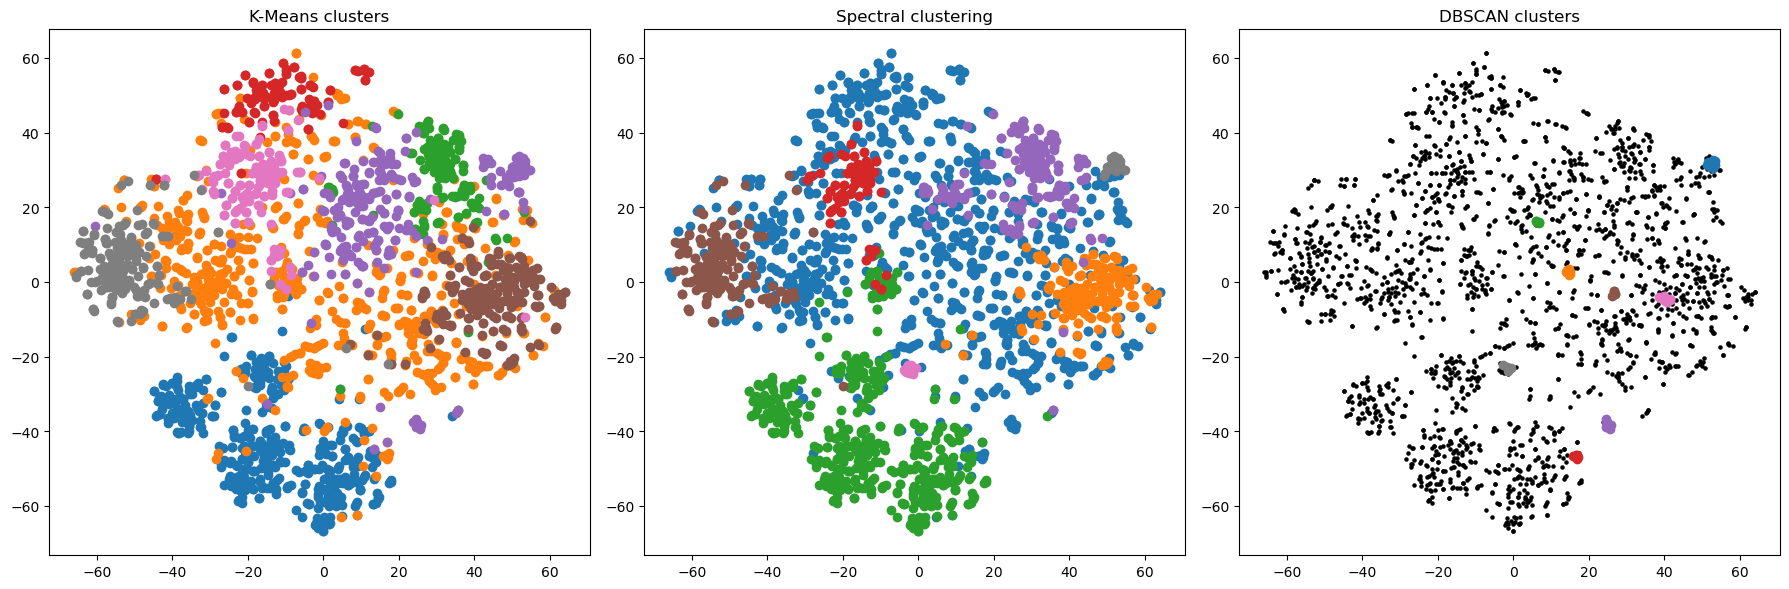

In [117]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, random_state=42, perplexity=30, max_iter=1000)
X_tsne = tsne.fit_transform(X_tfidf.toarray())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

def plot_clusters(ax, X_tsne, labels, title, is_dbscan=False):
    for label in np.unique(labels):
        if is_dbscan and label == -1:
            mask = (labels == -1)
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c="black", s=5, label="Noise")
        else:
            mask = (labels == label)
            ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], label=f"Cluster {label}")
    ax.set_title(title)

plot_clusters(axes[0], X_tsne, cluster_labels_kmeans, "K-Means clusters", is_dbscan=False)

plot_clusters(axes[1], X_tsne, labels_spectral, "Spectral clustering", is_dbscan=False)

plot_clusters(axes[2], X_tsne, labels_dbscan, "DBSCAN clusters", is_dbscan=True)

plt.tight_layout()
plt.show()

Прокомментируйте получившиеся результаты. Какой баланс кластеров получился у разных методов? Соотносятся ли визуализации для текстов с визуализациями для географических данных?

**Ответ:** лучший баланс явно у kmeans. Разбиение у спектральной кластеризации тоже неплохое, равномерное, но есть синий кластер который явно преобладает, а такого не должно быть

Соотносятся ли визуализации для текстов с визуализациями для географических данных?
Да, соотносятся, на географических данных спектральная кластеризация тоже жадно выделила большой кластер, тогда как kmeans разбил его на несколько разных

DBSCAN отработал ужасно, не знаю в чем проблема

**Задание 2.4 (1.5 балла).** Обучите модель латентного размещения Дирихле. Не забудьте, что она работает с мешком слов, а не с tf-idf признаками. Придумайте, как превратить распределение тем для текста в номер его кластера. Возьмите параметр `n_components` в 2-3 раза больше, чем число кластеров для K-Means.

In [120]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

vectorizer = CountVectorizer(
    max_df=0.5,
    min_df=5,
    max_features=5000
)
X_bow = vectorizer.fit_transform(data["text"])

lda = LatentDirichletAllocation(
    n_components=20,
    random_state=42,
    max_iter=10
)
lda.fit(X_bow)

topic_probs = lda.transform(X_bow)

cluster_labels = np.argmax(topic_probs, axis=1)

print("Размеры кластеров:", np.bincount(cluster_labels))

Размеры кластеров: [182 242 115 179 186  93 144 114  40  37 134 128  54  39 104  32  79  32
  95 196]


Topic 1: 242 документов


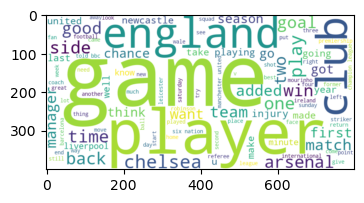

Topic 19: 196 документов


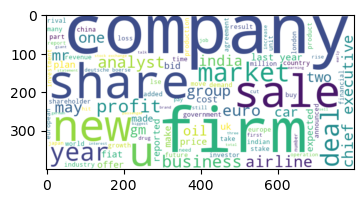

Topic 4: 186 документов


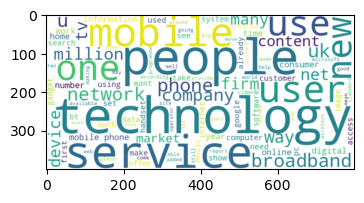

Topic 0: 182 документов


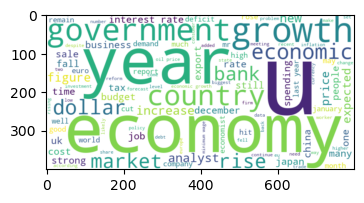

Topic 3: 179 документов


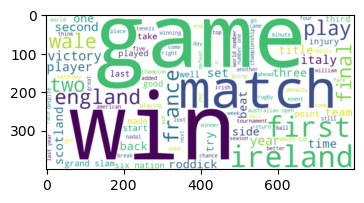

Topic 6: 144 документов


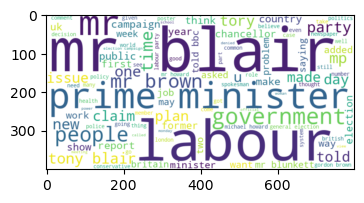

Topic 10: 134 документов


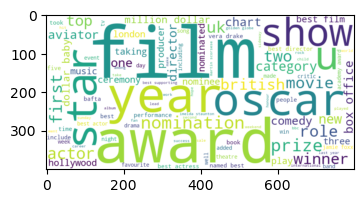

Topic 11: 128 документов


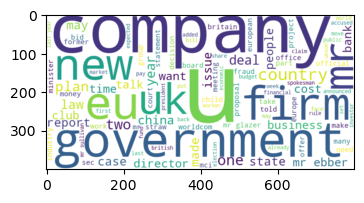

In [121]:
cluster_sizes = np.bincount(cluster_labels)
top_topics = np.argsort(cluster_sizes)[-8:][::-1]  # 8 самых больших

for cl in top_topics:
    texts_in_cluster = data[cluster_labels == cl]["text"]
    print(f"Topic {cl}: {len(texts_in_cluster)} документов")
    plot_wordcloud_for_cluster(cl, texts_in_cluster)


Получились ли темы более узкими от такого нововведения? Постройте облака тегов для нескольких наиболее удачных тем.

**Ответ:** да, темы более узкие и определенные, хороший и интерпретируемый результат

## Часть 3. Transfer learning и Self-Supervised Learning для задачи классификации текстов

**Задание 3.1 (0.5 балла).** Вспомним, что у нас есть разметка для тематик статей. Попробуем обучить классификатор поверх unsupervised-представлений для текстов. Рассмотрите три модели:

* Логистическая регрессия на tf-idf признаках
* K-Means на tf-idf признаках + логистическая регрессия на расстояниях до центров кластеров
* Латентное размещение Дирихле + логистическая регрессия на вероятностях тем

Разделите выборку на обучающую и тестовую, замерьте accuracy на обоих выборках для всех трех моделей. Параметры всех моделей возьмите равными значениям по умолчанию.

In [201]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

y = data["category"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

logreg = LogisticRegression()
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       1.00      0.97      0.99       102
entertainment       0.99      1.00      0.99        77
     politics       0.99      0.98      0.98        84
        sport       0.99      1.00      1.00       102
         tech       0.98      1.00      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445



In [150]:
n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, n_init=10, random_state=42)
kmeans.fit(X_tfidf)

centers = kmeans.cluster_centers_

distances_to_centers = np.zeros((X_tfidf.shape[0], n_clusters))

for i in range(n_clusters):
    distances_to_centers[:, i] = np.linalg.norm(X_tfidf - centers[i], axis=1)

X_cluster_distances = distances_to_centers

y = data["category"].values
X_train, X_test, y_train, y_test = train_test_split(
    X_cluster_distances, y, test_size=0.2, random_state=42, stratify=y
)

logreg_distances = LogisticRegression()
logreg_distances.fit(X_train, y_train)

y_pred_distances = logreg_distances.predict(X_test)
accuracy_distances = accuracy_score(y_test, y_pred_distances)

print(classification_report(y_test, y_pred_distances))

               precision    recall  f1-score   support

     business       0.92      0.96      0.94       102
entertainment       1.00      0.62      0.77        77
     politics       0.95      0.74      0.83        84
        sport       0.68      1.00      0.81       102
         tech       0.97      0.91      0.94        80

     accuracy                           0.86       445
    macro avg       0.90      0.85      0.86       445
 weighted avg       0.89      0.86      0.86       445



In [202]:
from sklearn.decomposition import LatentDirichletAllocation

texts = data["text"].values

vectorizer = CountVectorizer(max_df=0.5, min_df=5, max_features=5000)
X_counts = vectorizer.fit_transform(texts)

n_topics = 20
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
topic_probs = lda.fit_transform(X_counts)

X_train, X_test, y_train, y_test = train_test_split(
    topic_probs, y, test_size=0.2, random_state=42, stratify=y
)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)

y_pred = logreg.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       0.94      0.92      0.93       102
entertainment       0.96      0.95      0.95        77
     politics       0.89      0.88      0.89        84
        sport       0.97      0.98      0.98       102
         tech       0.93      0.96      0.94        80

     accuracy                           0.94       445
    macro avg       0.94      0.94      0.94       445
 weighted avg       0.94      0.94      0.94       445



У какой модели получилось лучшее качество? С чем это связано?

**Ответ:** лучшее качество у обычного логрега на tfidf, потом логрег на lda. результат на lda хуже, потому что мы сжимаем темы, упрощаем пространство.

kmeans + tfidf хуже всего, потому что учитывает геометрическую близость, а не тематическую, как это делают алгоритмы выше

**Задание 3.2 (1.5 балла).** Теперь просимулируем ситуацию слабой разметки, которая часто встречается в реальных данных. Разделим обучающую выборку в пропорции 5:65:30. Будем называть части, соответственно, размеченный трейн, неразмеченный трейн и валидация.

Все unsupervised-алгоритмы (векторайзеры и алгоритмы кластеризации) запускайте на всем трейне целиком (размеченном и неразмеченном, суммарно 70%), а итоговый классификатор обучайте только на размеченном трейне (5%). Подберите гиперпараметры моделей по качеству на валидации (30%), а затем оцените качество на тестовой выборке (которая осталась от прошлого задания). Не скромничайте при подборе числа кластеров, сейчас нас интересует не интерпретируемое разбиение выборки, а итоговое качество классификации.

In [189]:
from sklearn.metrics.pairwise import pairwise_distances

data_train, data_test, y_train, y_test = train_test_split(
    data, data["category"], test_size=0.3, random_state=42, stratify=data["category"]
)

train_full, val, y_train_full, y_val = train_test_split(
    data_train, y_train, test_size=0.3, random_state=42, stratify=y_train
)

labeled, unlabeled, y_labeled, y_unlabeled = train_test_split(
    train_full, y_train_full, train_size=5/70, random_state=42, stratify=y_train_full
)

vectorizer = TfidfVectorizer(max_df=0.5, min_df=5, max_features=5000)
X_train_full = vectorizer.fit_transform(pd.concat([labeled, unlabeled])["text"])
X_labeled = vectorizer.transform(labeled["text"])
X_val = vectorizer.transform(val["text"])
X_test = vectorizer.transform(data_test["text"])

best_c = 1.0
best_val = 0
for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
    lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
    lr.fit(X_labeled, y_labeled)
    acc = accuracy_score(y_val, lr.predict(X_val))
    print(f"  C={C:5.2f} -> val_acc={acc:.3f}")
    if acc > best_val:
        best_val = acc
        best_c = C
lr_tfidf = LogisticRegression(C=best_c, max_iter=1000, random_state=42)
lr_tfidf.fit(X_labeled, y_labeled)
test_acc1 = accuracy_score(y_test, lr_tfidf.predict(X_test))

best_k = 10
best_val_k = 0
best_c_for_best_k = 1.0
k_range = [10, 20, 30, 50, 80, 100, 150, 200, 300, 500]

for k in k_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X_train_full)
    dist_labeled = pairwise_distances(X_labeled, km.cluster_centers_)
    dist_val = pairwise_distances(X_val, km.cluster_centers_)
    
    best_c_k = 1.0
    best_acc_k = 0
    for C in [0.01, 0.1, 1.0, 10.0, 100.0]:
        lr = LogisticRegression(C=C, max_iter=1000, random_state=42)
        lr.fit(dist_labeled, y_labeled)
        acc = accuracy_score(y_val, lr.predict(dist_val))
        if acc > best_acc_k:
            best_acc_k = acc
            best_c_k = C
    print(f"  k={k:3d} -> val_acc={best_acc_k:.3f} (C={best_c_k})")
    if best_acc_k > best_val_k:
        best_val_k = best_acc_k
        best_k = k
        best_c_for_best_k = best_c_k


km_final = KMeans(n_clusters=best_k, n_init=10, random_state=42)
km_final.fit(X_train_full)
dist_labeled_final = pairwise_distances(X_labeled, km_final.cluster_centers_)
dist_test = pairwise_distances(X_test, km_final.cluster_centers_)
lr_kmeans = LogisticRegression(C=best_c_for_best_k, max_iter=1000, random_state=42)
lr_kmeans.fit(dist_labeled_final, y_labeled)
test_acc2 = accuracy_score(y_test, lr_kmeans.predict(dist_test))

count_vec = CountVectorizer(max_df=0.5, min_df=5, max_features=5000)
X_train_full_cnt = count_vec.fit_transform(pd.concat([labeled, unlabeled])["text"])
X_labeled_cnt = count_vec.transform(labeled["text"])
X_val_cnt = count_vec.transform(val["text"])
X_test_cnt = count_vec.transform(data_test["text"])

best_n = 10
best_val_lda = 0
n_range = [10, 20, 30, 50, 80, 100, 150, 200]
for n in n_range:
    lda = LatentDirichletAllocation(n_components=n, random_state=42, max_iter=20)
    lda.fit(X_train_full_cnt)
    topics_labeled = lda.transform(X_labeled_cnt)
    topics_val = lda.transform(X_val_cnt)
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(topics_labeled, y_labeled)
    acc = accuracy_score(y_val, lr.predict(topics_val))
    print(f"  n_topics={n:3d} -> val_acc={acc:.3f}")
    if acc > best_val_lda:
        best_val_lda = acc
        best_n = n

lda_final = LatentDirichletAllocation(n_components=best_n, random_state=42, max_iter=20)
lda_final.fit(X_train_full_cnt)
topics_labeled_final = lda_final.transform(X_labeled_cnt)
topics_test = lda_final.transform(X_test_cnt)
lr_lda = LogisticRegression(max_iter=1000, random_state=42)
lr_lda.fit(topics_labeled_final, y_labeled)
test_acc3 = accuracy_score(y_test, lr_lda.predict(topics_test))

print(f"  LR на TF‑IDF:                {test_acc1:.3f}")
print(f"  KMeans + LR (расстояния):   {test_acc2:.3f}")
print(f"  LDA + LR (вероятности тем): {test_acc3:.3f}")

  C= 0.01 -> val_acc=0.449
  C= 0.10 -> val_acc=0.449
  C= 1.00 -> val_acc=0.842
  C=10.00 -> val_acc=0.917
  C=100.00 -> val_acc=0.929
  k= 10 -> val_acc=0.927 (C=100.0)
  k= 20 -> val_acc=0.944 (C=100.0)
  k= 30 -> val_acc=0.951 (C=100.0)
  k= 50 -> val_acc=0.947 (C=100.0)
  k= 80 -> val_acc=0.944 (C=100.0)
  k=100 -> val_acc=0.953 (C=100.0)
  k=150 -> val_acc=0.955 (C=100.0)
  k=200 -> val_acc=0.955 (C=100.0)
  k=300 -> val_acc=0.953 (C=100.0)
  k=500 -> val_acc=0.947 (C=10.0)
  n_topics= 10 -> val_acc=0.925
  n_topics= 20 -> val_acc=0.962
  n_topics= 30 -> val_acc=0.944
  n_topics= 50 -> val_acc=0.910
  n_topics= 80 -> val_acc=0.831
  n_topics=100 -> val_acc=0.793
  n_topics=150 -> val_acc=0.675
  n_topics=200 -> val_acc=0.598
  LR на TF‑IDF:                0.912
  KMeans + LR (расстояния):   0.960
  LDA + LR (вероятности тем): 0.940


Как изменились результаты по сравнению с обучением на полной разметке? Сделайте выводы.

**Ответ:** даже при слабой разметке мы получили отличные метрики (конечно под вопросом то, что мы выбрали большое количество кластеров). Лучший результат у логрега на расстояниях до центра + kmeans

LDA тоже дал высокое качество

## Бонус

**Задание 4 (0.5 балла)**. Разберитесь с semi-supervised методами, которые реализованы в `sklearn` и примените их к заданию 3.2. Получилось ли добиться лучшего качества? Сделайте выводы.

In [198]:
from sklearn.semi_supervised import SelfTrainingClassifier, LabelSpreading
from sklearn.preprocessing import LabelEncoder

X_semi = X_train_full
y_semi = np.concatenate([y_labeled, np.full(len(unlabeled), -1)])

all_labels = np.unique(np.concatenate([y_labeled, y_val, y_test]))
le = LabelEncoder()
le.fit(all_labels)
y_semi_enc = np.array([le.transform([label])[0] if label != -1 else -1 for label in y_semi])
y_val_enc = le.transform(y_val)

best_thresh = 0.75
best_C = 1.0
best_val_st = 0

for C in [0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]:
    for thresh in [0.75, 0.8, 0.85, 0.9, 0.95]:
        base_clf = LogisticRegression(C=C, max_iter=1000, class_weight='balanced', random_state=42)
        st = SelfTrainingClassifier(base_clf, threshold=thresh, max_iter=20)
        st.fit(X_semi, y_semi)
        acc = accuracy_score(y_val, st.predict(X_val))
        print(f"C={C}, threshold={thresh}: val_acc={acc:.3f}")
        if acc > best_val_st:
            best_val_st = acc
            best_thresh = thresh
            best_C = C

base_clf_best = LogisticRegression(C=best_C, max_iter=1000, random_state=42)
st_final = SelfTrainingClassifier(base_clf_best, threshold=best_thresh, max_iter=20)
st_final.fit(X_semi, y_semi)
st_test_acc = accuracy_score(y_test, st_final.predict(X_test))

best_nn = 1
best_alpha = 0.2
best_val_ls = 0
for nn in [1, 2, 5, 7, 10, 12, 15, 20, 22]:
    for alpha in [0.1, 0.2, 0.3]:
        ls = LabelSpreading(kernel='rbf', n_neighbors=nn, alpha=alpha, max_iter=100)
        ls.fit(X_semi, y_semi_enc)
        val_pred_enc = ls.predict(X_val)
        acc = accuracy_score(y_val_enc, val_pred_enc)
        print(f"  n_neighbors={nn}, alpha={alpha}: val_acc={acc:.3f}")
        if acc > best_val_ls:
            best_val_ls = acc
            best_nn = nn
            best_alpha = alpha
ls_final = LabelSpreading(kernel = 'rbf', n_neighbors=best_nn, alpha=best_alpha, max_iter=100)
ls_final.fit(X_semi, y_semi_enc)
ls_test_pred_enc = ls_final.predict(X_test)
ls_test_pred = le.inverse_transform(ls_test_pred_enc)
ls_test_acc = accuracy_score(y_test, ls_test_pred)

print(f"  LR на TF‑IDF (baseline):            {test_acc1:.3f}")
print(f"  KMeans + LR (расстояния):          {test_acc2:.3f}")
print(f"  LDA + LR (вероятности тем):        {test_acc3:.3f}")
print(f"  SelfTrainingClassifier:            {st_test_acc:.3f}")
print(f"  LabelSpreading:                    {ls_test_acc:.3f}")

C=0.01, threshold=0.75: val_acc=0.934
C=0.01, threshold=0.8: val_acc=0.934
C=0.01, threshold=0.85: val_acc=0.934
C=0.01, threshold=0.9: val_acc=0.934
C=0.01, threshold=0.95: val_acc=0.934
C=0.1, threshold=0.75: val_acc=0.938
C=0.1, threshold=0.8: val_acc=0.938
C=0.1, threshold=0.85: val_acc=0.938
C=0.1, threshold=0.9: val_acc=0.938
C=0.1, threshold=0.95: val_acc=0.938
C=0.5, threshold=0.75: val_acc=0.932
C=0.5, threshold=0.8: val_acc=0.932
C=0.5, threshold=0.85: val_acc=0.932
C=0.5, threshold=0.9: val_acc=0.932
C=0.5, threshold=0.95: val_acc=0.932
C=1.0, threshold=0.75: val_acc=0.932
C=1.0, threshold=0.8: val_acc=0.932
C=1.0, threshold=0.85: val_acc=0.932
C=1.0, threshold=0.9: val_acc=0.932
C=1.0, threshold=0.95: val_acc=0.932
C=5.0, threshold=0.75: val_acc=0.902
C=5.0, threshold=0.8: val_acc=0.936
C=5.0, threshold=0.85: val_acc=0.932
C=5.0, threshold=0.9: val_acc=0.932
C=5.0, threshold=0.95: val_acc=0.932
C=10.0, threshold=0.75: val_acc=0.919
C=10.0, threshold=0.8: val_acc=0.906
C=10.

выводы: 

Semi-supervised методы из sklearn  при правильной настройке позволяют добиться лучшего качества по сравнению с прошлыми подходами. Однако это требует тщательного подбора гиперпараметров (особенно C для базовой модели). LabelSpreading в данном эксперименте оказался неэффективен, по сравнению с алгоритмами рядом, но тоже показал достойный результат, дал бой

**Задание 5 (1 балл)**. На занятиях мы обсуждали, что метрика [BCubed](https://www.researchgate.net/profile/Julio-Gonzalo-2/publication/225548032_Amigo_E_Gonzalo_J_Artiles_J_et_alA_comparison_of_extrinsic_clustering_evaluation_metrics_based_on_formal_constraints_Inform_Retriev_12461-486/links/0c96052138dbb99740000000/Amigo-E-Gonzalo-J-Artiles-J-et-alA-comparison-of-extrinsic-clustering-evaluation-metrics-based-on-formal-constraints-Inform-Retriev-12461-486.pdf) хорошо подходит для сравнения алгоритмов кластеризации, если нам известно настоящее разделение на кластеры (gold standard). Реализуйте подсчет метрики BCubed и сравните несколько алгоритмов кластеризации на текстовых данных из основного задания. В качестве gold standard используйте разметку category.

In [199]:
from sklearn.metrics import confusion_matrix

def bcubed(labels_true, labels_pred):

    n = len(labels_true)

    total_precision = 0.0
    total_recall = 0.0
    
    for i in range(n):
        same_cluster = [j for j in range(n) if labels_pred[j] == labels_pred[i]]
        same_true = [j for j in range(n) if labels_true[j] == labels_true[i]]
        intersection = set(same_cluster) & set(same_true)
        common = len(intersection)
        
        precision_i = common / len(same_cluster) if same_cluster else 0
        recall_i = common / len(same_true) if same_true else 0
        
        total_precision += precision_i
        total_recall += recall_i
    
    precision = total_precision / n
    recall = total_recall / n
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    return precision, recall, f1

In [205]:
y_true = data['category'].values
texts = data['text'].values

n_true = len(np.unique(y_true))
kmeans = KMeans(n_clusters=n_true, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X_tfidf)

count_vec = CountVectorizer(max_df=0.5, min_df=5, max_features=5000)
X_counts = count_vec.fit_transform(texts)
lda = LatentDirichletAllocation(n_components=n_true, random_state=42, max_iter=20)
lda.fit(X_counts)
topic_probs = lda.transform(X_counts)
y_lda = np.argmax(topic_probs, axis=1)

p_k, r_k, f_k = bcubed(y_true, y_kmeans)
p_l, r_l, f_l = bcubed(y_true, y_lda)

print(f"KMeans (clusters={n_true}): Precision={p_k:.4f}, Recall={r_k:.4f}, F1={f_k:.4f}")
print(f"LDA (topics={n_true}):      Precision={p_l:.4f}, Recall={r_l:.4f}, F1={f_l:.4f}")

KMeans (clusters=5): Precision=0.7508, Recall=0.5095, F1=0.6071
LDA (topics=5):      Precision=0.6472, Recall=0.7262, F1=0.6844


kmeans показал хороший результат в точности, но не в обобщении и ф1, в отличии от LDA, который неплохо справился

**Задание 6 (2 баллa)**. Спектральная кластеризация, по сути, является обычной кластеризацией KMeans поверх эмбеддингов объектов, которые получаются из лапласиана графа. А что, если мы попробуем построить эмбеддинги каким-нибудь другим способом? В этом задании мы предлагаем вам проявить немного фантазии. Возьмите какие-нибудь данные высокой размерности, чтобы задача обучения эмбеддингов имела смысл (например, картинки или тексты, желательно выбрать что-нибудь оригинальное). Придумайте или найдите какой-нибудь метод обучения эмбеддингов, примените его к данным и кластеризуйте полученные представления. Если чувствуете в себе достаточно силы, можете попробовать что-нибудь нейросетевое. Сравните ваш подход с базовыми алгоритмами кластеризации, которое мы рассмотрели в основном задании, не забывайте про визуализации! Ключевые слова для вдохновения: ***KernelPCA***, ***UMAP***, ***autoencoders***, ***gensim***.

In [210]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.2/46.2 MB 846.7 kB/s  0:00:52 eta 0:00:010:00:02


In [212]:
import cv2
from sklearn.datasets import load_files
from sklearn.decomposition import KernelPCA

data_path = "chest_xray/train"
dataset = load_files(data_path, shuffle=False)

X_raw = []
y = []
for img_path, label in zip(dataset['filenames'], dataset['target']):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is not None:
        img_resized = cv2.resize(img, (128, 128))
        X_raw.append(img_resized.flatten())
        y.append(label)

X = np.array(X_raw)
y = np.array(y)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_raw = KMeans(n_clusters=2, random_state=42, n_init=10)
y_raw = kmeans_raw.fit_predict(X_scaled)

kpca = KernelPCA(n_components=50, kernel='rbf', gamma=0.001, random_state=42)
X_kpca = kpca.fit_transform(X_scaled)
kmeans_kpca = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kpca = kmeans_kpca.fit_predict(X_kpca)

p_raw, r_raw, f_raw = bcubed(y, y_raw)
p_kpca, r_kpca, f_kpca = bcubed(y, y_kpca)

print(f"KMeans на пикселях:      Precision={p_raw:.4f}, Recall={r_raw:.4f}, F1={f_raw:.4f}")
print(f"KMeans на KernelPCA:     Precision={p_kpca:.4f}, Recall={r_kpca:.4f}, F1={f_kpca:.4f}")

KMeans на пикселях:      Precision=0.6197, Recall=0.5215, F1=0.5664
KMeans на KernelPCA:     Precision=0.6181, Recall=0.9989, F1=0.7636


для задачи кластеризации пневмонии рекол почти 1 очень хорошо, потому что нам надо уловить саму болезнь, даже пускай что там будут зжоровые люди (ложноположительные)

f1 сильно вырос, результат в целом неплохой, kernelpca с rbf ядром сильно помог (точность почти такая же)

проведем эксперимент с подбором гиперпараметров для kernelpca с rbf ядром

In [221]:
best_f1 = 0
best_n = None
best_gamma = None

for n_comp in [10, 20, 30, 50, 75, 100]:
    for gamma in [0.0001, 0.001, 0.01, 0.05, 0.1]:
        kpca = KernelPCA(n_components=n_comp, kernel='rbf', gamma=gamma, random_state=42)
        X_kpca = kpca.fit_transform(X_scaled)
        km = KMeans(n_clusters=2, random_state=42, n_init=10)
        y_pred = km.fit_predict(X_kpca)
        _, _, f1 = bcubed(y, y_pred)
        if f1 > best_f1:
            best_f1 = f1
            best_n = n_comp
            best_gamma = gamma


kpca_best = KernelPCA(n_components=best_n, kernel='rbf', gamma=best_gamma, random_state=42)
X_kpca_full = kpca_best.fit_transform(X_scaled)
km_best = KMeans(n_clusters=2, random_state=42, n_init=10)
y_kpca_best = km_best.fit_predict(X_kpca_full)
_,_,f1_best = bcubed(y, y_kpca_best)

print(f"KMeans на пикселях:          BCubed F1 = {f_raw:.4f}")
print(f"KernelPCA + KMeans: BCubed F1 = {f1_best:.4f}")

KMeans на пикселях:          BCubed F1 = 0.5664
KernelPCA + KMeans: BCubed F1 = 0.7640


качество при подборе параметров не выросло

**Задание 7 (1 балл)**. Наконец, ставший ежегодной традицией социализационный бонус. Мы поощряем не только предметное, но и духовное развитие. Поэтому, чтобы заработать балл за это задание, сходите на какую-нибудь выставку, в музей, театр, или наконец в церковь, напишите небольшой отчетик о ваших впечатлениях и добавьте фотопруфы в ноутбук при сдаче. Можете объединиться с одногруппниками/однокурсниками, а также пригласить ассистентов/преподавателей, они тоже будут рады выбраться куда-нибудь. Для вдохновения приведем ссылку на актуальные выставки [новой](https://www.youtube.com/watch?v=dQw4w9WgXcQ&ab) и [старой Третьяковки](https://www.youtube.com/watch?v=xm3YgoEiEDc) (но совсем не обязательно посещать именно их).

In [ ]:
# YOUR CODE HERE (ノಠ益ಠ)ノ彡┻━┻

# я быдло(